In [1]:
%%capture
!pip install datasets
!pip install transformers
import datasets
import pandas as pd
!pip install seaborn
import seaborn as sns
import transformers
!pip install shap
import shap
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
!pip install lime
import lime
from lime.lime_text import LimeTextExplainer
from lime import submodular_pick
import matplotlib.pyplot as plt
import numpy as np

## XAI approaches for black-box models

When using black-box models for a target task, model explainability is typically achieved using post-hoc interpretation XAI approaches. In this tutorial we focus on feature importance XAI approaches that aim to identify the most important features for the prediction of a complex AI model. By clarifying which features influence a model’s predictions, XAI allows users to verify the model’s reasoning, identify potential biases or errors, and make more informed decisions based on its outputs.

Various XAI feature importance approaches exist and they can be applied at different levels:

*   **Global explanations** help understand the overall behavior of a model across all inputs.
*   **Local explanations** focus on individual predictions, showing why the model made a specific decision for a single case.


In the following we look at two very popular ones, namely, `lime` and `shap`.
Both methods are model-agnostic, making them versatile tools to interpret black-box models such as deep neural networks and ensemble methods.

## LIME
The core principle of LIME is that even if an AI model behaves non-linearly across the entire input space, it can be approximated locally by a simpler, interpretable model. To explain a specific prediction, LIME perturbs the input data around the instance of interest and observes how these perturbations affect the model's output. It then fits an interpretable model to these perturbed samples, weighting them according to their proximity to the original instance.

This local surrogate model captures the decision boundary of the complex model in the neighborhood of the instance being explained, providing insights into which features contributed most to that particular prediction.

LIME provides **local explanations only** as it focuses on explaining individual predictions. It approximates a complex model locally around a single instance using a simpler interpretable model, such as a linear regression.

**SP-LIME (Submodular Pick LIME)** extends LIME with the capablity to provide more global understanding of the model's behaviour. SP-LIME applies a submodular optimization algorithm to select a small, diverse, and representative set of instances from the target dataset. By explaining these carefully chosen instances with LIME, SP-LIME provides a more comprehensive picture of model behaviour across different types of inputs.

SP-LIME balances two objectives:
* **Coverage**: the selected instances collectively cover as many important features as possible.
* **Non-redundancy**: the selected instances avoid repeating the same explanations, so each new instance adds new information.

This makes the set of SP-LIME explanations jointly more informative than a random subset of equal size, providing a global view of feature importances for the ML model.

### LIME example
We will now use `LIME` explainability for a Random Forest model trained on YouTube spam classifications. We first train a model on the labeled comments (spam or not) from videos by PSY, Shakira, LMFAO, and Katy Perry. Then we apply `LIME` and `SP-LIME` as a post-hoc explainability approaches, to obtain both local explanations for the feature importance of target samples and global feature importances through a selection of a diverse and representative instances for explanation, respectively.

### Model training
We train a `Random Forest Classifier` model to identify spam comments of youtube videos using a labelled dataset.

In [2]:
# Load data
psy = pd.read_csv('https://raw.githubusercontent.com/JasminaZHAW/XAI/refs/heads/main/data/Youtube01-Psy.csv')
perry = pd.read_csv('https://raw.githubusercontent.com/JasminaZHAW/XAI/refs/heads/main/data/Youtube02-KatyPerry.csv')
LMFAO = pd.read_csv('https://raw.githubusercontent.com/JasminaZHAW/XAI/refs/heads/main/data/Youtube03-LMFAO.csv')
Eminem = pd.read_csv('https://raw.githubusercontent.com/JasminaZHAW/XAI/refs/heads/main/data/Youtube04-Eminem.csv')
Shakira = pd.read_csv('https://raw.githubusercontent.com/JasminaZHAW/XAI/refs/heads/main/data/Youtube05-Shakira.csv')
full_train = pd.concat([psy, perry, LMFAO, Shakira, Eminem]).reset_index().drop(columns = ['index'])

In [3]:
display(full_train.head(3))

,COMMENT_ID,AUTHOR,DATE,CONTENT,CLASS
0,LZQPQhLyRh80UYxNuaDWhIGQYNQ96IuCg-AYWqNPjpU,Julius NM,2013-11-07T06:20:48,"Huh, anyway check out this you[tube] channel: ...",1
1,LZQPQhLyRh_C2cTtd9MvFRJedxydaVW-2sNg5Diuo4A,adam riyati,2013-11-07T12:37:15,Hey guys check out my new channel and our firs...,1
2,LZQPQhLyRh9MSZYnf8djyk0gEF9BHDPYrrK-qCczIY8,Evgeny Murashkin,2013-11-08T17:34:21,just for test I have to say murdev.com,1


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from lime.lime_text import LimeTextExplainer

# Prepare data for model training
X= full_train['CONTENT']
y= full_train['CLASS']

# Feature representation for the text input
tfidf = TfidfVectorizer(ngram_range=(1, 1), stop_words="english")

features = tfidf.fit_transform(X)

X_tfidf = pd.DataFrame(features.todense(), columns=tfidf.get_feature_names_out())

# Create training and test data
X_train_text, X_test_text, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=13)
X_train, X_test, _, _ = train_test_split(X_tfidf.fillna(0), y, test_size=0.3, stratify=y, random_state=13)

# Fit a random forest classifier with 100 trees
rf_clf = RandomForestClassifier(max_features=2, n_estimators =100 ,bootstrap=True)

rf_clf.fit(X_train, y_train)

# Inference on the test set (predictions on the test set samples)
def predict_proba_text(texts):
    text_tfidf = tfidf.transform(texts)
    text_df = pd.DataFrame(text_tfidf.toarray(), columns=tfidf.get_feature_names_out())
    return rf_clf.predict_proba(text_df)

# Model performance on the test set
y_pred = rf_clf.predict(X_test)
print(classification_report(y_pred, y_test))


              precision    recall  f1-score   support

           0       0.99      0.91      0.95       309
           1       0.91      0.99      0.94       278

    accuracy                           0.95       587
   macro avg       0.95      0.95      0.95       587
weighted avg       0.95      0.95      0.95       587



### Local Feature Importance
In order to visualize how LIME attributes importance to each feature for a specific instance,  we plot the feature importance weights below.  

We choose one spam and one non-spam sample from the test set and create a barplot that explains the feature importances for each, showing the weights (both positive and negative) of words impacting the explanation. This visualization shows which words (features) contributed most to the model classifying a comment as spam or non-spam.

In [5]:
import warnings
# Suppress the harmless LIME info warning when pool size equals or exceeds sample_size
warnings.filterwarnings('ignore', message='Requested sample size', category=UserWarning)

class_names = ['Not spam', 'Spam']

feature_names = list(X_train.columns)

lime_text = LimeTextExplainer(class_names=class_names)


SPAM Comment: If interested in making extra money by internet use the next link www.swagbucks.com/refer/Nonturtle02﻿...

NOT SPAM Comment: the most viewed youtube video of all time?﻿...


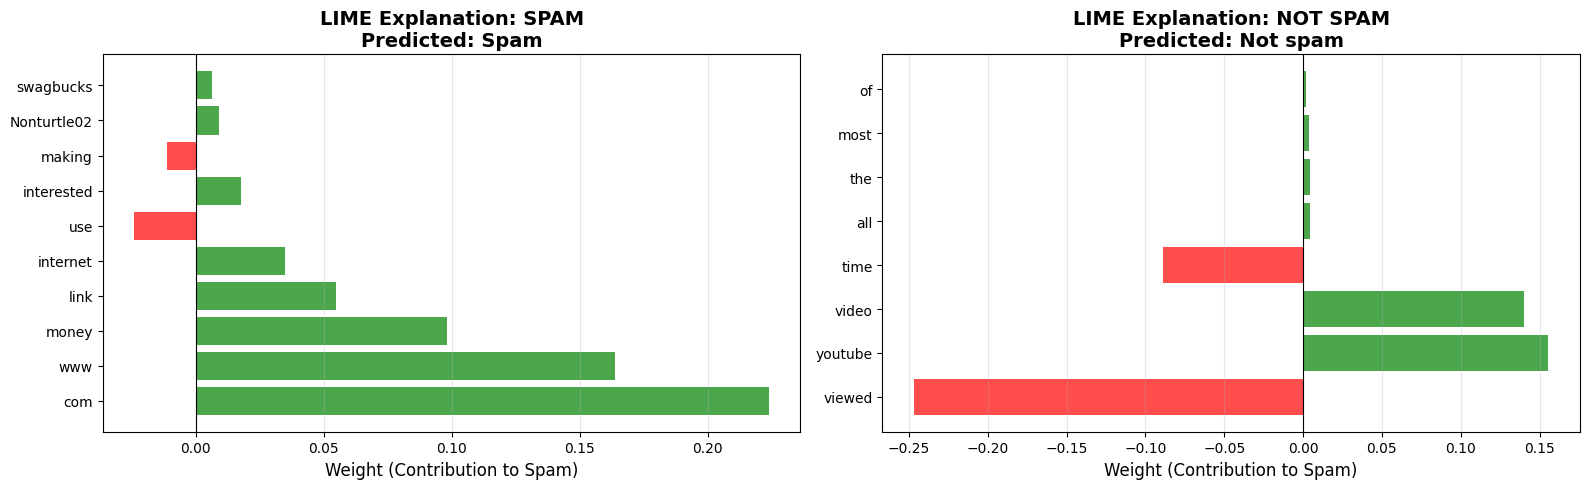

In [6]:
# Select two samples, one spam one non-spam
spam_idx = y_test[y_test == 1].index[0]
non_spam_idx = y_test[y_test == 0].index[0]

# Plot feature importances for the spam and not smap samples
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, (example_idx, label) in enumerate([(spam_idx, 'SPAM'),
                                            (non_spam_idx, 'NOT SPAM')]):
    text = X_test_text.loc[example_idx]
    exp = lime_text.explain_instance(text, predict_proba_text, num_features=10)

    feat_imp = exp.as_list()
    words = [f[0] for f in feat_imp]
    weights = [f[1] for f in feat_imp]

    colors = ['green' if w > 0 else 'red' for w in weights]
    axes[idx].barh(words, weights, color=colors, alpha=0.7)

    pred_class = np.argmax(exp.predict_proba)
    axes[idx].set_xlabel('Weight (Contribution to Spam)', fontsize=12)
    axes[idx].set_title(f'LIME Explanation: {label}\nPredicted: {class_names[pred_class]}',
                        fontsize=14, fontweight='bold')
    axes[idx].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    axes[idx].grid(axis='x', alpha=0.3)
    print(f"\n{label} Comment: {text[:200]}...")

plt.tight_layout()
plt.show()

### Feature importance across multiple samples
Next, we extend our analysis to understand global model behaviour.

SP-LIME uses submodular optimization to select a diverse, non-redundant set of representative instances from the test set. Rather than randomly sampling instances, SP-LIME actively chooses instances that together cover as many important features as possible, giving a more informative view of the model's overall behaviour.

We run SP-LIME on a pool of test samples and examine the feature importance distribution across the selected instances. We compute the average importance per feature and how frequently each feature appears across the selected SP-LIME explanations. This helps us understand which features consistently influence the model across different representative examples.

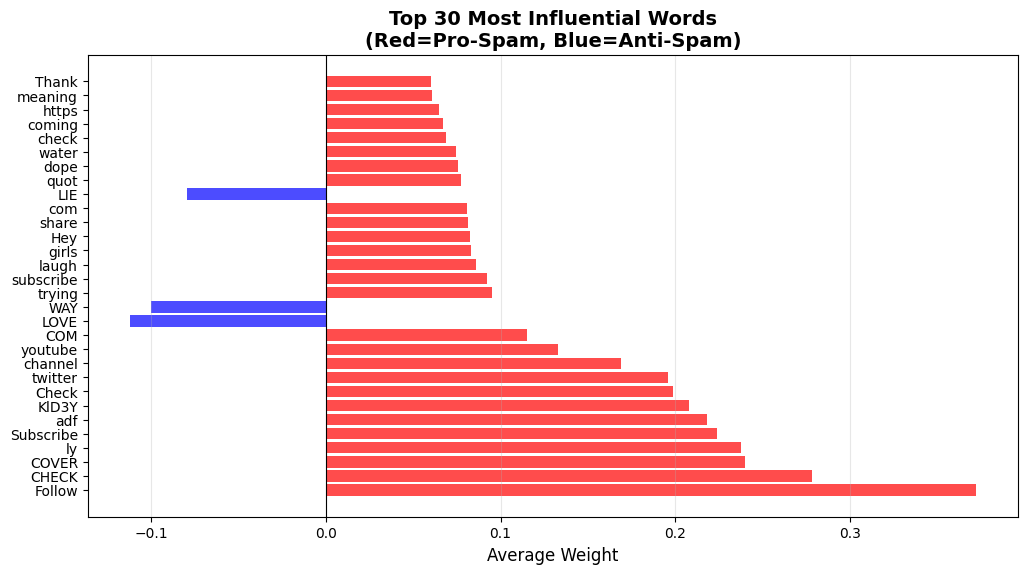

In [7]:
n_pool = 100    # Pool of candidates for SP-LIME to evaluate
n_selected = 20  # Number of diverse instances SP-LIME will select

# Select a random pool of candidates from the test set
np.random.seed(42)
pool_indices = np.random.choice(len(X_test_text), n_pool, replace=False)
pool_texts = list(X_test_text.iloc[pool_indices])

# SP-LIME selects a diverse, non-redundant subset that maximises feature coverage
sp_multi = submodular_pick.SubmodularPick(
    lime_text, pool_texts, predict_proba_text,
    num_features=15, num_exps_desired=n_selected, top_labels=0
)

# Compute word (feature) importance from SP-LIME selected explanations
word_importance = {}

for exp in sp_multi.sp_explanations:
    for word, weight in exp.as_list():
        if word not in word_importance:
            word_importance[word] = []
        word_importance[word].append(weight)

word_stats = {
    word: {
        'mean': np.mean(weights),
        'std': np.std(weights),
        'count': len(weights)
    }
    for word, weights in word_importance.items()
}

# Sort by absolute mean importance
sorted_words = sorted(word_stats.items(), key=lambda x: abs(x[1]['mean']), reverse=True)[:30]

# Plot: Average importance
plt.figure(figsize=(12, 6))

words = [w[0] for w in sorted_words]
means = [w[1]['mean'] for w in sorted_words]
colors = ['red' if m > 0 else 'blue' for m in means]

plt.barh(words, means, color=colors, alpha=0.7)
plt.xlabel('Average Weight', fontsize=12)
plt.title('Top 30 Most Influential Words\n(Red=Pro-Spam, Blue=Anti-Spam)',
              fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)

plt.show()

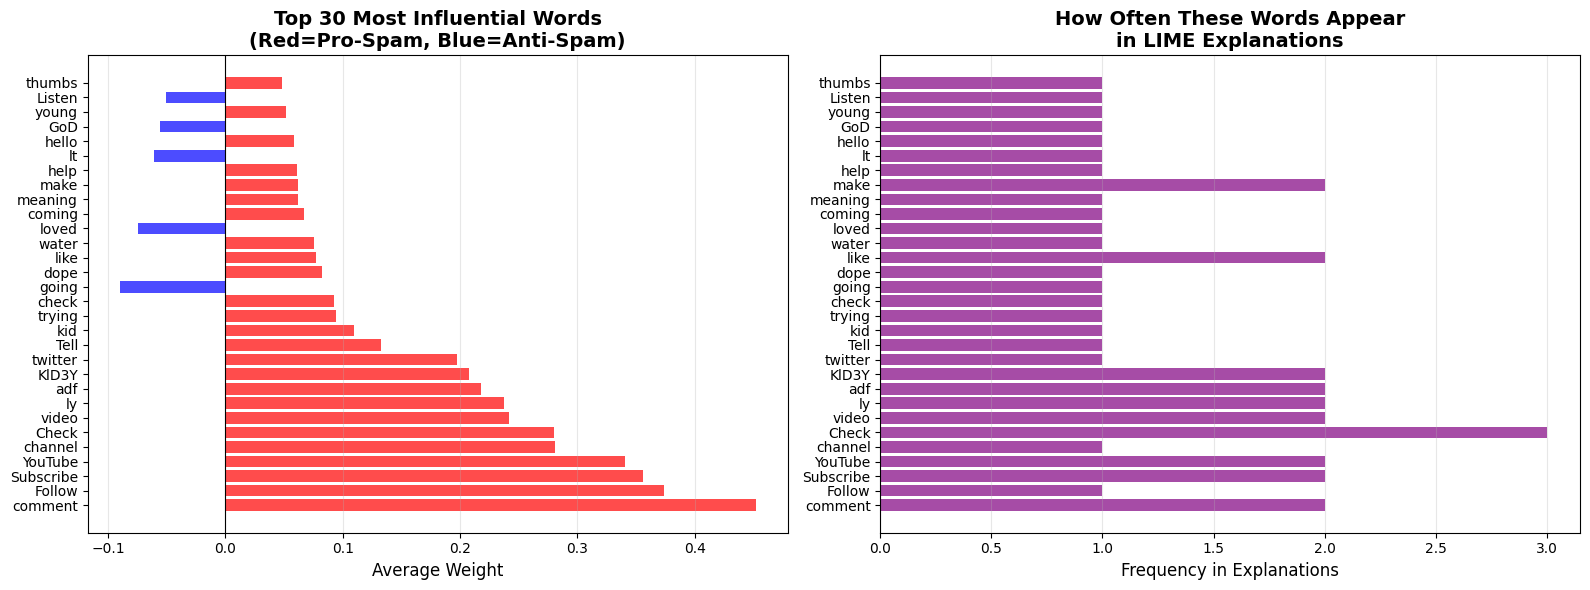

In [8]:
# Compare to random sample selection combined with LIME
# Select 20 random samples from the target set (the 100 samples selected previously)
n_samples = 20
sample_20 = np.random.choice(len(X_test_text.iloc[pool_indices]), n_samples, replace=False)

set_20 = list(X_test_text.iloc[pool_indices])

# Compute word (feature) importance for the selected samples using lime
word_importance = {}

for idx in range(len(sample_20)):
    text = set_20[sample_20[idx]]
    exp = lime_text.explain_instance(text, predict_proba_text, num_features=15)

    for word, weight in exp.as_list():
        if word not in word_importance:
            word_importance[word] = []
        word_importance[word].append(weight)

# Calculate statistics over the computed importances
word_stats = {
    word: {
        'mean': np.mean(weights),
        'std': np.std(weights),
        'count': len(weights)
    }
    for word, weights in word_importance.items()
    # if len(weights) >= 3  # Only words appearing in at least 3 explanations
}

# Sort by absolute mean importance
sorted_words = sorted(word_stats.items(), key=lambda x: abs(x[1]['mean']), reverse=True)[:30]

# Visualize importances
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Average importance
words = [w[0] for w in sorted_words]
means = [w[1]['mean'] for w in sorted_words]
colors = ['red' if m > 0 else 'blue' for m in means]

ax1.barh(words, means, color=colors, alpha=0.7)
ax1.set_xlabel('Average Weight', fontsize=12)
ax1.set_title('Top 30 Most Influential Words\n(Red=Pro-Spam, Blue=Anti-Spam)',
              fontsize=14, fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax1.grid(axis='x', alpha=0.3)

# Plot 2: Frequency of appearance
counts = [w[1]['count'] for w in sorted_words]
ax2.barh(words, counts, color='purple', alpha=0.7)
ax2.set_xlabel('Frequency in Explanations', fontsize=12)
ax2.set_title('How Often These Words Appear\nin LIME Explanations',
              fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### SP-LIME Feature Coverage vs Random Selection

SP-LIME greedily selects instances whose explanations together cover the most frequently occurring features across all candidates. We count how many features are covered by SP-LIME and compare it to random selection.

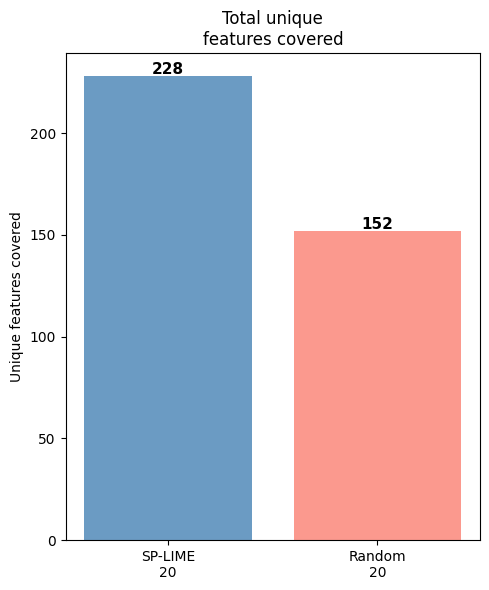

Unique features in full-100 pool: 466
SP-LIME 20 covers: 228/466 unique features (49%)
Random  20 covers: 152/466 unique features (33%)


In [9]:
from collections import Counter

np.random.seed(42)

# Full 100-instance pool: count how often each word appears in LIME explanations
full_counter = Counter()
all_exp_features = []
for exp in sp_multi.explanations:
    words = [f[0] for f in exp.as_list()]
    all_exp_features.append(words)
    full_counter.update(words)

# SP-LIME selected 20
sp_counter = Counter()
for exp in sp_multi.sp_explanations:
    sp_counter.update([f[0] for f in exp.as_list()])

# Random 20 from the same pool
random_20_idxs = np.random.choice(len(all_exp_features), 20, replace=False)
rand_counter = Counter()
for i in random_20_idxs:
    rand_counter.update(all_exp_features[i])

# Total unique features covered
n_full      = len(full_counter)
sp_unique   = sum(1 for w in full_counter if sp_counter[w]   > 0)
rand_unique = sum(1 for w in full_counter if rand_counter[w] > 0)

# Plot: unique features covered only
fig, ax2 = plt.subplots(figsize=(5, 6))

ax2.bar(['SP-LIME\n20', 'Random\n20'],
        [sp_unique, rand_unique],
        color=['steelblue', 'salmon'], alpha=0.8)
ax2.set_ylabel('Unique features covered')
ax2.set_title('Total unique\nfeatures covered')
for i, v in enumerate([sp_unique, rand_unique]):
    ax2.text(i, v + 1, str(v), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Unique features in full-100 pool: {n_full}')
print(f'SP-LIME 20 covers: {sp_unique}/{n_full} unique features ({sp_unique/n_full*100:.0f}%)')
print(f'Random  20 covers: {rand_unique}/{n_full} unique features ({rand_unique/n_full*100:.0f}%)')

The panel reveals SP-LIME covers substantially more unique features than random, because its diverse selection spreads across the full vocabulary rather than concentrating on the most frequent words.

## Common co-occurences
Finally, we summarize the most common co-occurrences of influential features across the SP-LIME selected instances selected before. We plot the most common pairs of words with positive influence on the class SPAM that co-occur across the SP-LIME selected samples. This analysis leverages SP-LIME's diverse selection to reveal patterns and feature combinations that the model relies on for spam detection, rather than focusing on a single instance or a random sample.

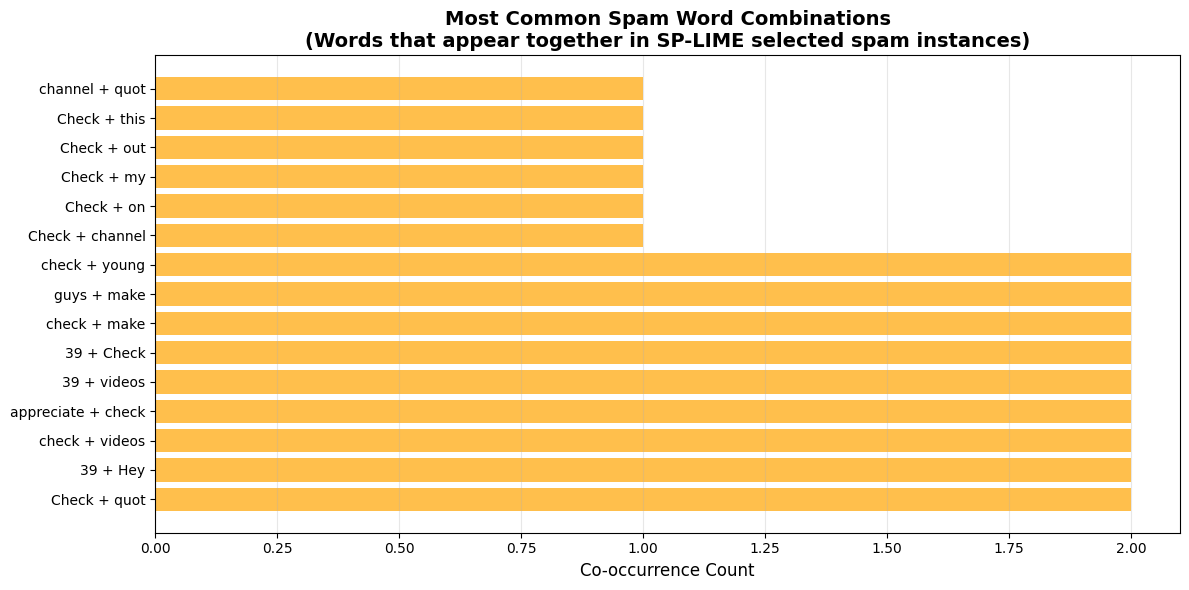

In [10]:
# Count co-ocurences of words selected by SP-LIME with positive contribution for the class SPAM
spam_word_pairs = {}

for exp in sp_multi.sp_explanations:
    spam_words_in_comment = [w for w, weight in exp.as_list() if weight > 0]

    # Count word pairs
    for i, w1 in enumerate(spam_words_in_comment):
        for w2 in spam_words_in_comment[i+1:]:
            pair = tuple(sorted([w1, w2]))
            spam_word_pairs[pair] = spam_word_pairs.get(pair, 0) + 1

# Plot
if spam_word_pairs:
    top_pairs = sorted(spam_word_pairs.items(), key=lambda x: x[1], reverse=True)[:15]
    pair_labels = [f"{p[0][0]} + {p[0][1]}" for p in top_pairs]
    pair_counts = [p[1] for p in top_pairs]

    plt.figure(figsize=(12, 6))
    plt.barh(pair_labels, pair_counts, color='orange', alpha=0.7)
    plt.xlabel('Co-occurrence Count', fontsize=12)
    plt.title('Most Common Spam Word Combinations\n(Words that appear together in SP-LIME selected spam instances)',
              fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

## SHAP (SHapley Additive exPlanations)

**SHAP** is a popular approach used for interpreting the output of machine learning models. It is based on the concept of Shapley values from cooperative game theory, which allocate the contribution of each feature to the model's predictions.

### How SHAP Works:
1. **Feature Contribution**: For each prediction, SHAP computes the contribution of each feature to the prediction by considering all possible feature combinations.
2. **Additive Feature Attribution**: The sum of SHAP values for all features equals the model’s prediction, ensuring consistency.


SHAP can provide both global and local explanations.



*   **Local**: For a single prediction, SHAP assigns a contribution value to each feature, showing exactly how it influenced that specific output.
*  **Global**: By aggregating SHAP values across many samples (e.g., averaging absolute contributions per feature), you can see which features are most important overall for the model.


### Example of a sentiment analisys model
Let's start with an example of `shap` over a `Sentiment Analisys` model.

For this example we will use a pretrained BERT model, and we will try to identify how each feature affects the final prediction.

In [11]:
%%capture
# Load the dataset
dataset = datasets.load_dataset("emotion", split="train")
data = pd.DataFrame({"text": dataset["text"], "emotion": dataset["label"]})

In [12]:
%%capture
# Load the model and tokenizer
tokenizer = transformers.AutoTokenizer.from_pretrained(
    "nateraw/bert-base-uncased-emotion", use_fast=True
)

model = transformers.AutoModelForSequenceClassification.from_pretrained(
    "nateraw/bert-base-uncased-emotion"
).cuda() # if this step fails, relaunch your google colab with a T4 runtime, ensuring cuda support or remove .cuda()

# Build a pipeline object to do predictions
pred = transformers.pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0, # change to -1 if not cuda (i.e. no GPU available)
    top_k=None,
)

In [13]:
# Build a SHAP explainer function
shap_explainer = shap.Explainer(pred, tokenizer)

In [14]:
import re
from IPython.display import display as _ipython_display, HTML
import shap

# adjusting shap plots.text to work with numpy 2.0 and get colors right
_orig_shap_text = shap.plots.text

def _patched_shap_text(shap_values, display=True, **kwargs):
    html = _orig_shap_text(shap_values, display=False, **kwargs)
    if html:
        html = re.sub(r'np\.float64\(([^)]+)\)', r'\1', html)
    if display:
        _ipython_display(HTML(html))
    else:
        return html

shap.plots.text = _patched_shap_text

In [15]:
# Plot the explainer
shap.initjs()
test_sample = ["I am happy to have followed the XAI lecture, and it is sad it is already over"]
shap_values = shap_explainer(test_sample)

shap.initjs()
shap.plots.text(shap_values[0])

In order to see how individual words contribute to the prediction for a specific emotion, we plot the SHAP text visualization below.  
This helps us understand which words increase or decrease the model's confidence for the each emotion class.

In [16]:
shap.plots.text(shap_values[:, :, "anger"])
shap.plots.text(shap_values[:, :, "joy"])
shap.plots.text(shap_values[:, :, "love"])
shap.plots.text(shap_values[:, :, "fear"])
shap.plots.text(shap_values[:, :, "surprise"])
shap.plots.text(shap_values[:, :, "sadness"])

### Importance of words in a sentence for different emotions
In order to see the weights of each word in a sentence for different emotions, we plot the following barplot. You can use the documentation available [here](https://shap.readthedocs.io/en/latest/example_notebooks/text_examples/sentiment_analysis/Emotion%20classification%20multiclass%20example.html).

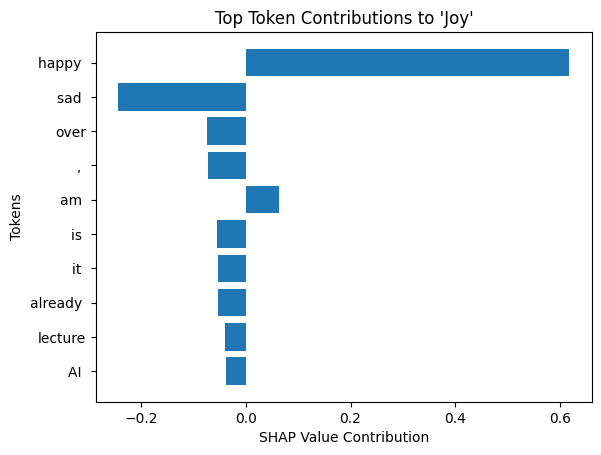

In [17]:
# Extract SHAP values for the 'joy' class
joy_index = 1  # Index of 'joy' in the model's output
joy_shap_values = shap_values.values[0, :, joy_index]

# Map tokens to their contributions
tokens = shap_values.data[0]  # Tokenized text
token_contributions = dict(zip(tokens, joy_shap_values))

import matplotlib.pyplot as plt

# Sort tokens by absolute contribution
sorted_contributions = sorted(token_contributions.items(), key=lambda x: abs(x[1]), reverse=True)

# Prepare data for plotting
sorted_tokens, sorted_values = zip(*sorted_contributions[:10])  # Top 10 tokens

plt.barh(sorted_tokens, sorted_values)
plt.xlabel("SHAP Value Contribution")
plt.ylabel("Tokens")
plt.title("Top Token Contributions to 'Joy'")
plt.gca().invert_yaxis()
plt.show()


### Contribution of words to prediction
The previous results can be visualized better with a waterfall barplot that shows how each token contributes to pushing the prediction from base value. This visualization helps us see the positive or negative impact of individual tokens on the model’s final prediction.

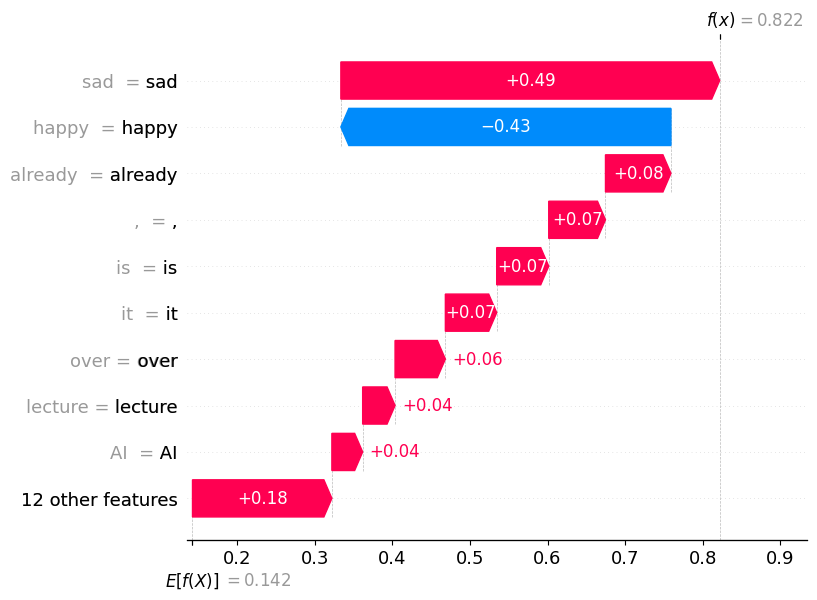

In [18]:
shap.plots.waterfall(shap_values[0, :, "sadness"])

### Most important words across all emotions
To gain a broader perspective, we now visualize the most important words across *all* emotion classes.  
This aggregated view helps us identify common linguistic patterns and which words are generally influencing model predictions the most.

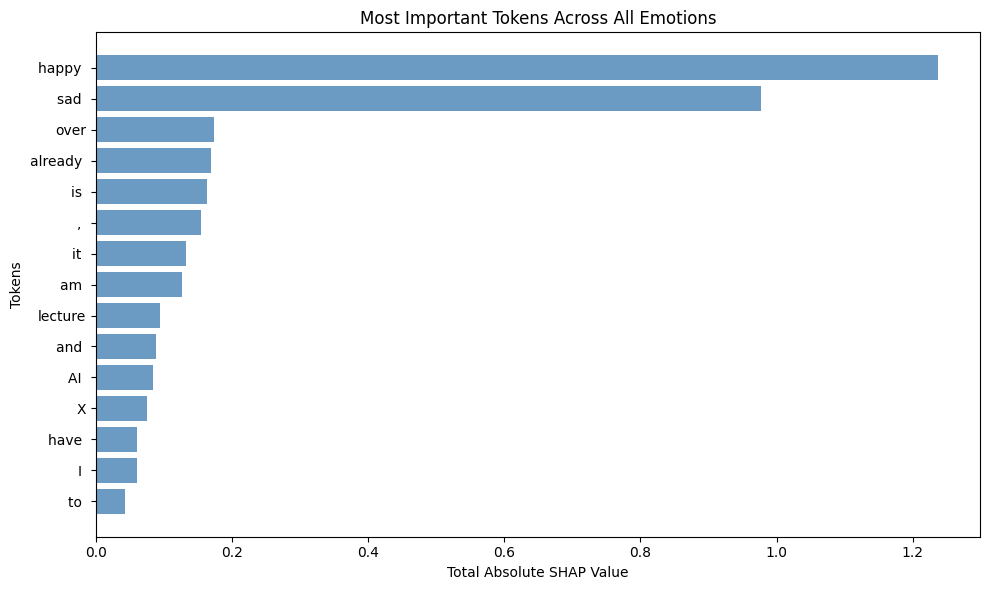

In [19]:
total_importance = np.abs(shap_values.values[0]).sum(axis=1)
token_importance = dict(zip(shap_values.data[0], total_importance))
sorted_importance = sorted(token_importance.items(), key=lambda x: x[1], reverse=True)

plt.figure(figsize=(10, 6))
tokens_plot, values_plot = zip(*sorted_importance[:15])
plt.barh(tokens_plot, values_plot, color='steelblue', alpha=0.8)
plt.xlabel('Total Absolute SHAP Value')
plt.ylabel('Tokens')
plt.title('Most Important Tokens Across All Emotions')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Summary

LIME provides a local view of model behavior by approximating the decision boundary near a single instance. This localized explanation can be valuable for understanding why a particular prediction occurred, even if it differs from the model’s general trends.

SHAP provides a more consistent, theoretically grounded measure of feature impact based on game thepry.

Both methods complement each other: SHAP for understanding general patterns, and LIME for exploring local decision behavior in depth.

SP-LIME extends LIME by using submodular optimization to select a small, diverse, and representative set of instances from a given target dataset and provide insights into the global model behavior. Rather than explaining a single arbitrarily chosen instance, SP-LIME identifies which instances are collectively most informative — covering different parts of the feature space while avoiding redundancy. This bridges the gap between purely local explanations and a more global understanding of the model's behaviour.

By aggregating SHAP values across many samples, one can obtain global model explanations.



